Assignment-12

**Random Forest**

In [119]:
import numpy as np
import pandas as pd

In [120]:
Excel =pd.ExcelFile('/content/glass.xlsx')

Excel.sheet_names

['Description', 'glass']

In [121]:
Excel=pd.read_excel('/content/glass.xlsx',sheet_name='glass')
Excel.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [122]:
df = Excel

In [123]:
df.shape

(214, 10)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [125]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [126]:
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


In [127]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [128]:
df.duplicated().sum()

np.int64(1)

In [129]:
df.drop_duplicates(inplace=True)

In [130]:
df.duplicated().sum()

np.int64(0)

In [131]:
df.dtypes

,0
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64


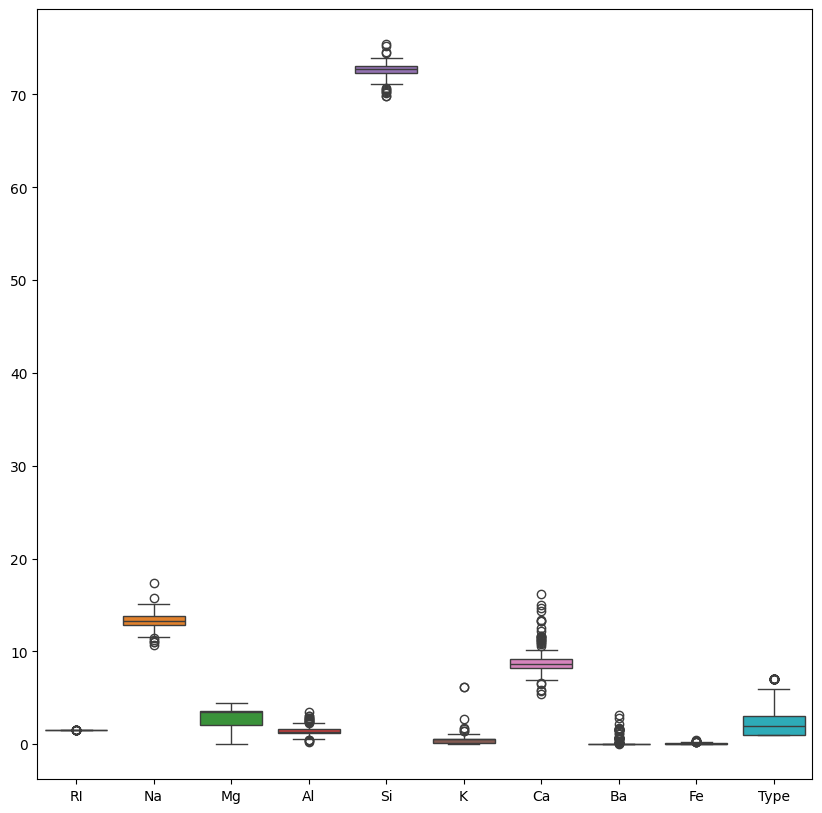

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,10))
sns.boxplot(df)
plt.show()

In [133]:
Q1= df['Na'].quantile(0.25)
Q3= df['Na'].quantile(0.75)
IQR= Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

print(lower)
print(upper)
print(IQR)

11.535
15.175
0.9100000000000001


In [134]:
df[(df['Na']<lower) | (df['Na']>upper)]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
105,1.52475,11.45,0.00,1.88,72.19,0.81,13.24,0.00,0.34,2
106,1.53125,10.73,0.00,2.10,69.81,0.58,13.30,3.15,0.28,2
110,1.52664,11.23,0.00,0.77,73.21,0.00,14.68,0.00,0.00,2
111,1.52739,11.02,0.00,0.75,73.08,0.00,14.96,0.00,0.00,2
166,1.52151,11.03,1.71,1.56,73.44,0.58,11.62,0.00,0.00,5
184,1.51115,17.38,0.00,0.34,75.41,0.00,6.65,0.00,0.00,6
189,1.52365,15.79,1.83,1.31,70.43,0.31,8.61,1.68,0.00,7


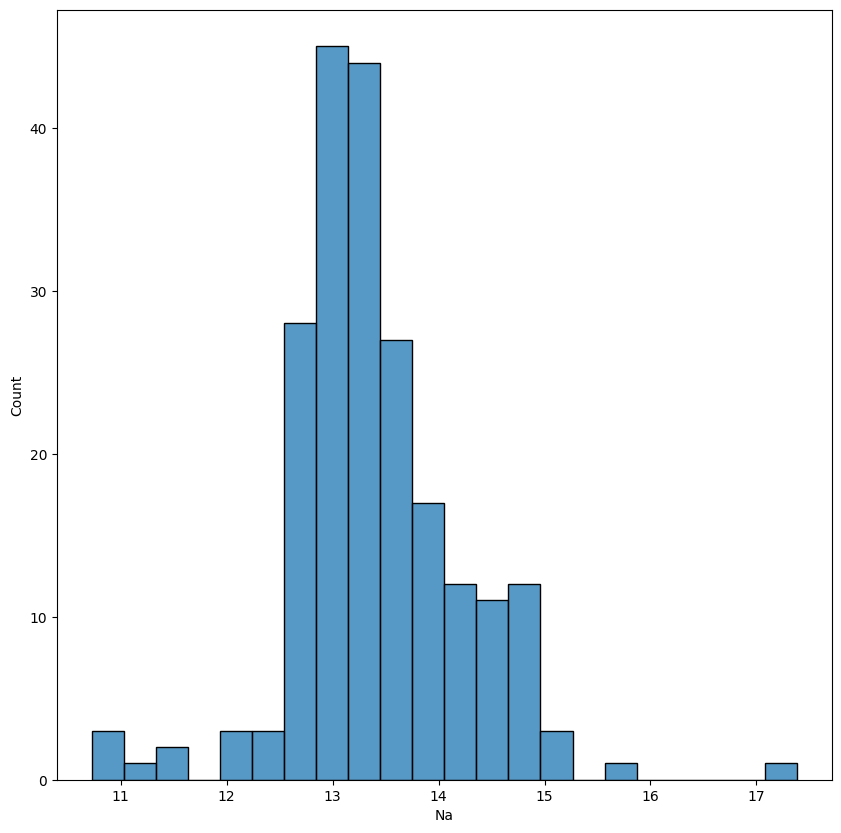

In [135]:
plt.figure(figsize=(10,10))
sns.histplot(df['Na'])
plt.show()

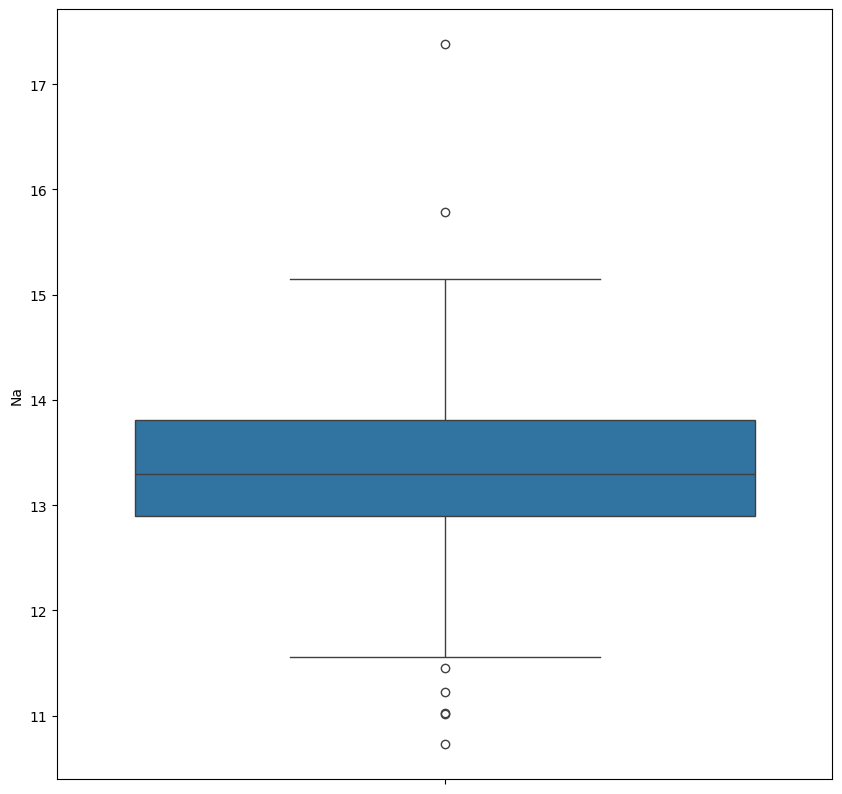

In [136]:
plt.figure(figsize=(10,10))
sns.boxplot(df['Na'])
plt.show()

<Figure size 1000x1000 with 0 Axes>

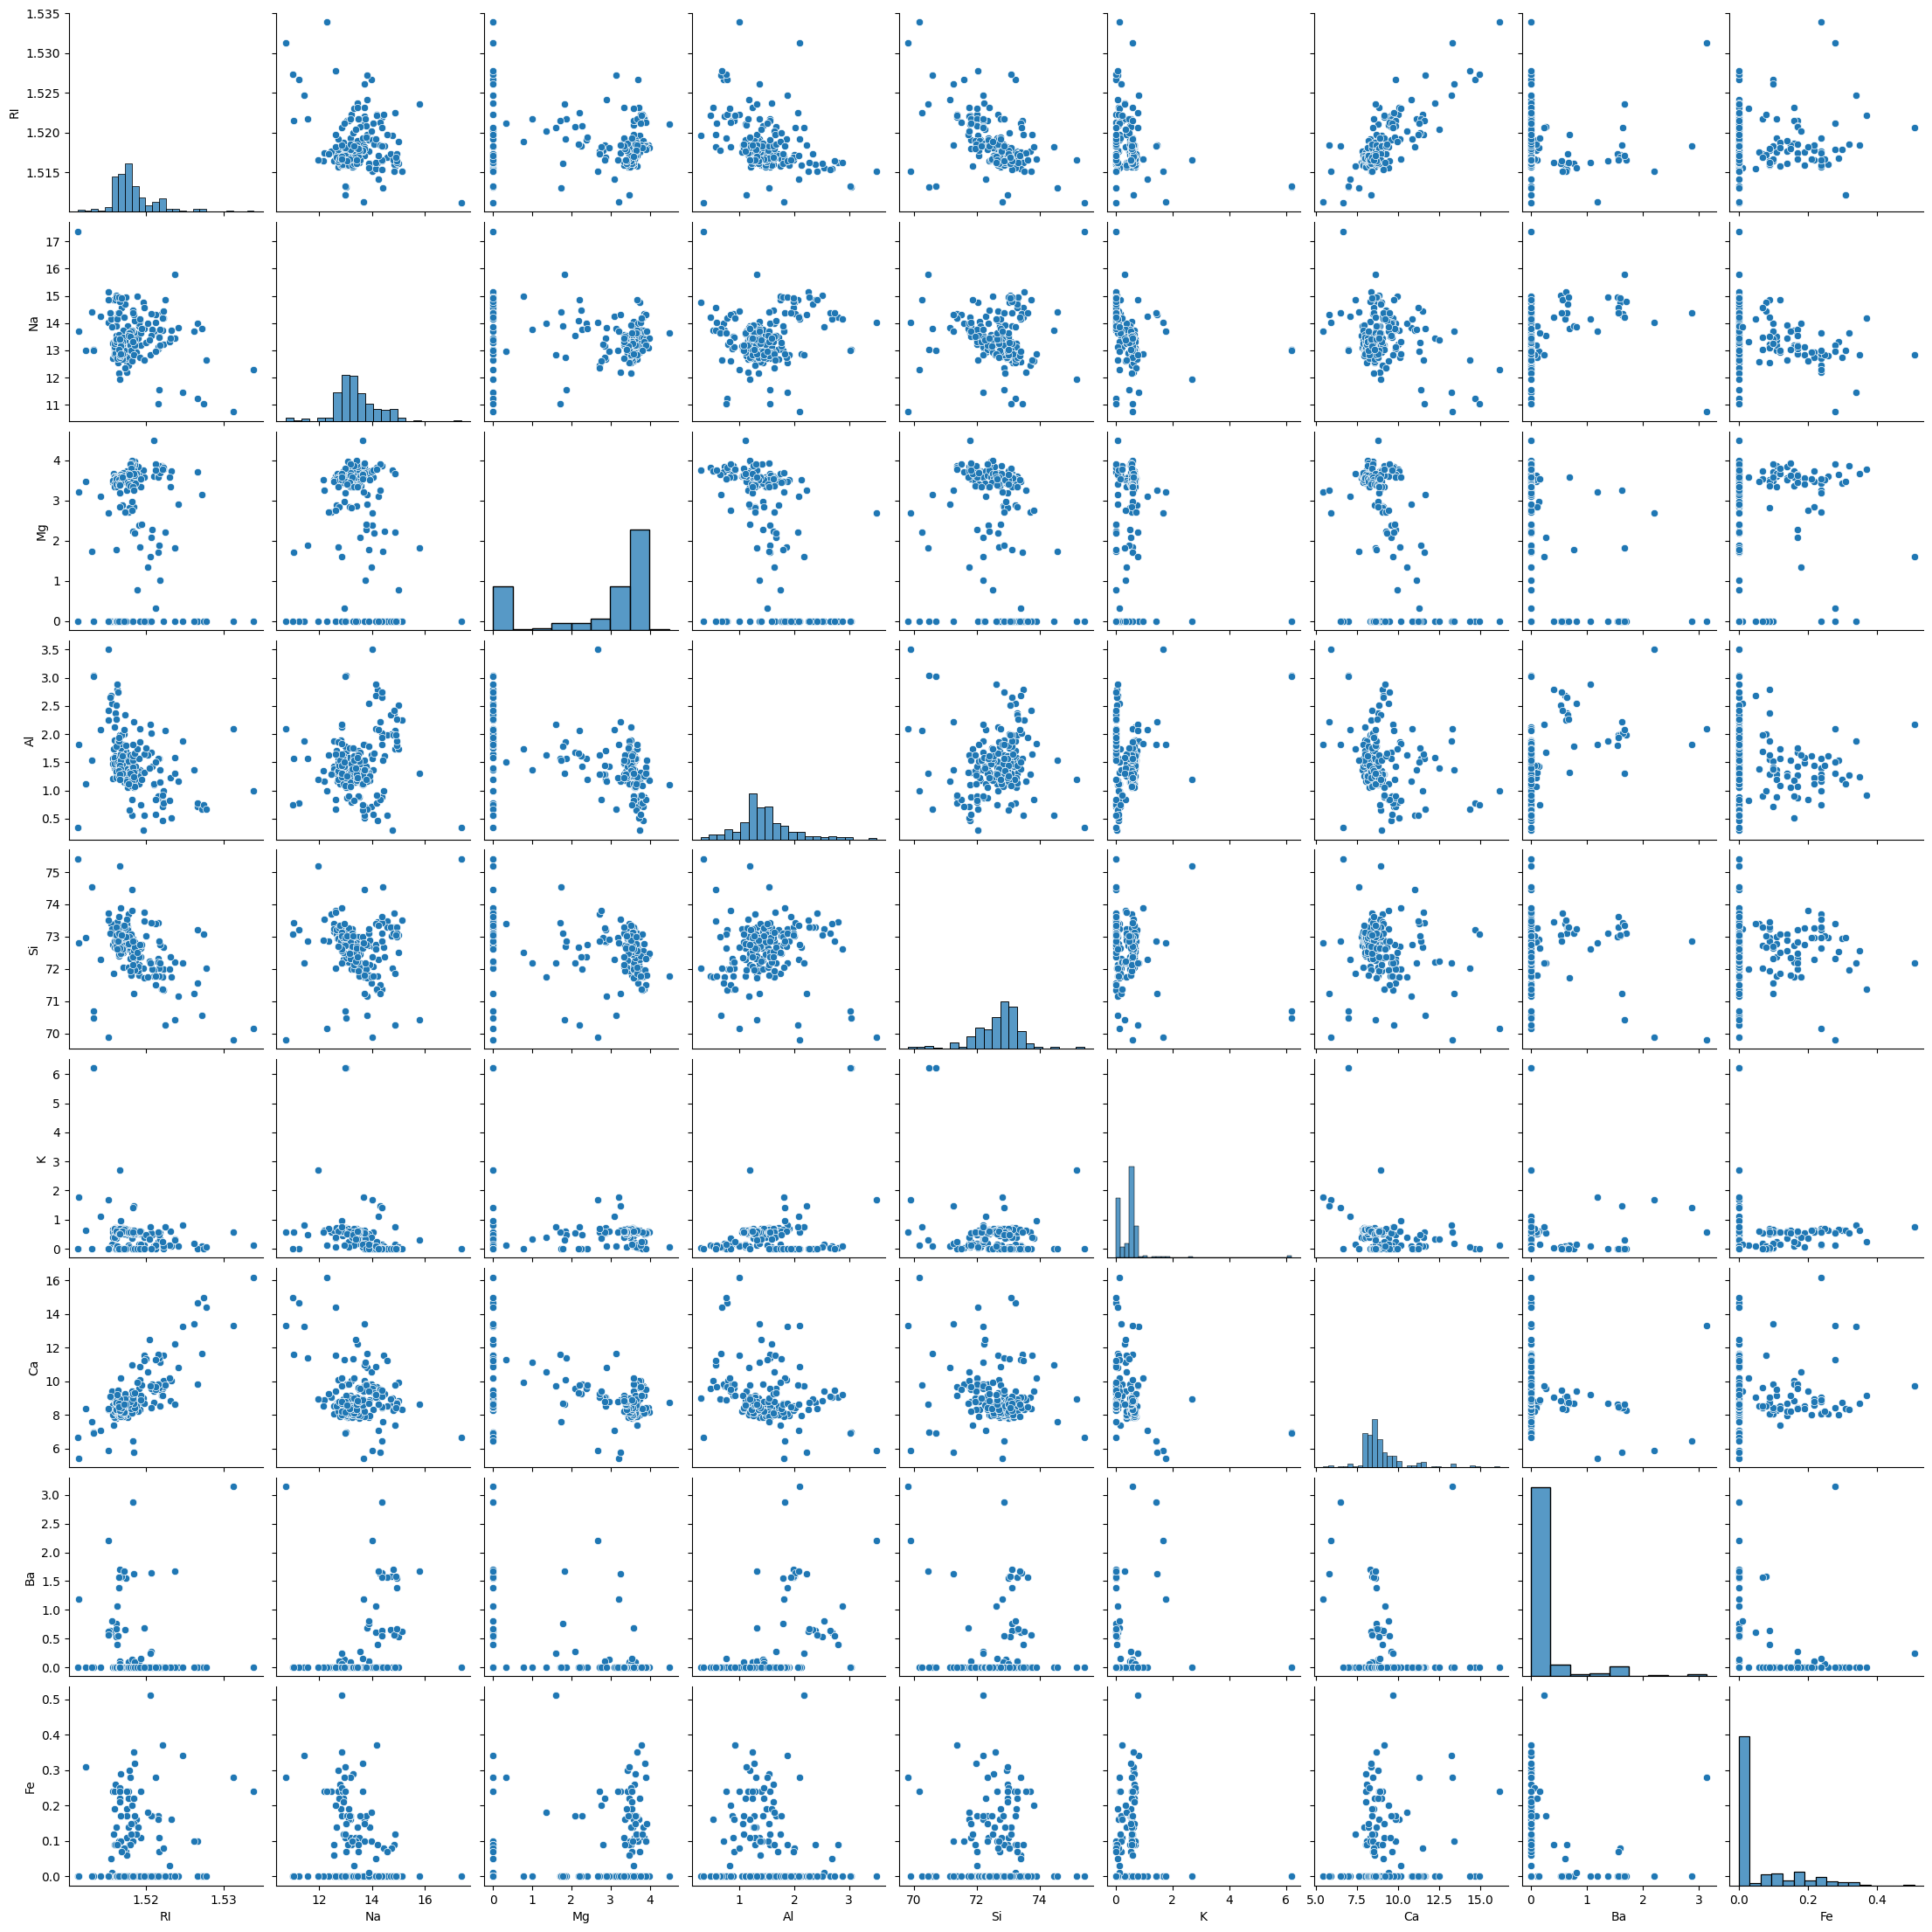

In [137]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.pairplot(df[['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']])
plt.show()

In [138]:
df['Type'].value_counts()

,count
Type,
2,76
1,69
7,29
3,17
5,13
6,9


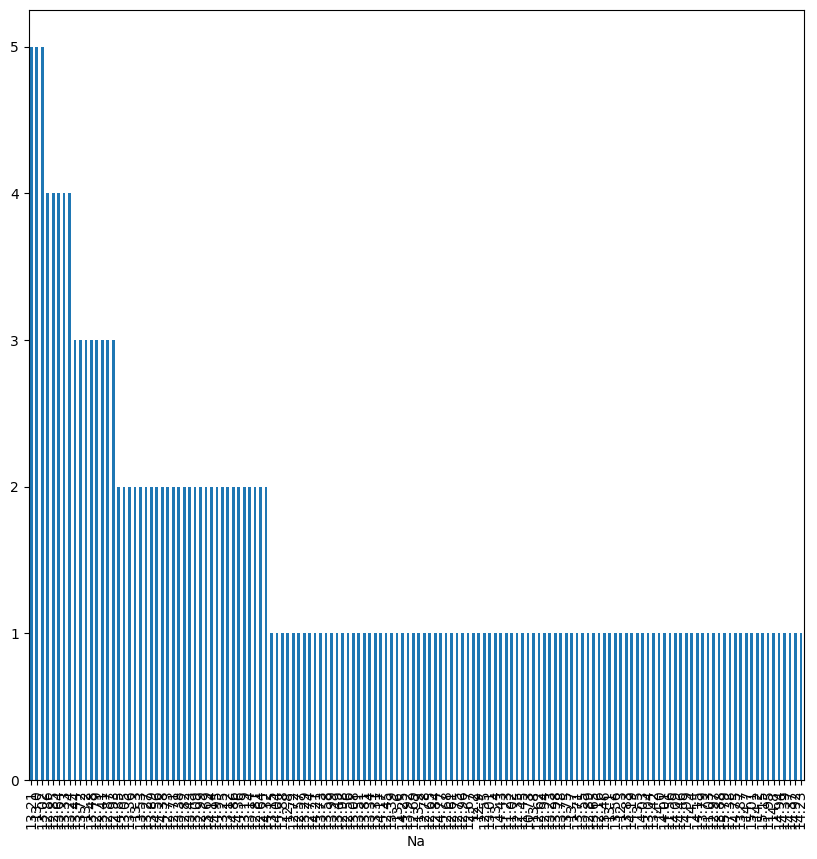

In [139]:
plt.figure(figsize=(10,10))
df['Na'].value_counts().plot(kind='bar')
plt.show()

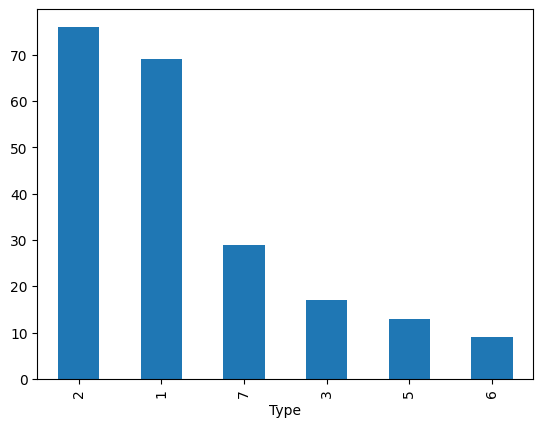

In [140]:
df['Type'].value_counts().plot(kind='bar')
plt.show()

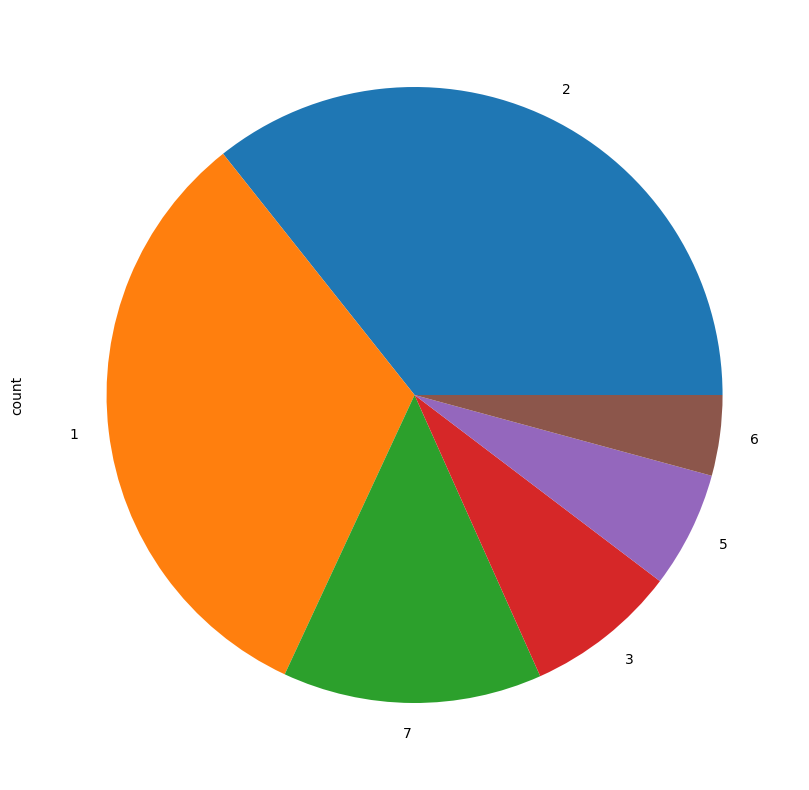

In [141]:
plt.figure(figsize=(10,10))
df['Type'].value_counts().plot(kind='pie')
plt.show()

In [142]:

df.corr(numeric_only=True)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.198802,-0.127526,-0.400973,-0.539000,-0.287645,0.811183,0.001679,0.147083,-0.160140
Na,-0.198802,1.000000,-0.278420,0.167735,-0.064885,-0.264158,-0.278194,0.329080,-0.239374,0.508837
Mg,-0.127526,-0.278420,1.000000,-0.479575,-0.162437,0.007617,-0.446197,-0.491818,0.085426,-0.744195
Al,-0.400973,0.167735,-0.479575,1.000000,-0.016195,0.323683,-0.258068,0.480642,-0.080583,0.597432
Si,-0.539000,-0.064885,-0.162437,-0.016195,1.000000,-0.197281,-0.207145,-0.104389,-0.097717,0.147725
K,-0.287645,-0.264158,0.007617,0.323683,-0.197281,1.000000,-0.317032,-0.043653,-0.009372,-0.012455
Ca,0.811183,-0.278194,-0.446197,-0.258068,-0.207145,-0.317032,1.000000,-0.112208,0.126314,0.002677
Ba,0.001679,0.329080,-0.491818,0.480642,-0.104389,-0.043653,-0.112208,1.000000,-0.059729,0.574896
Fe,0.147083,-0.239374,0.085426,-0.080583,-0.097717,-0.009372,0.126314,-0.059729,1.000000,-0.191090
Type,-0.160140,0.508837,-0.744195,0.597432,0.147725,-0.012455,0.002677,0.574896,-0.191090,1.000000


In [143]:
df.dtypes

,0
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64


In [144]:
df.duplicated().sum()

np.int64(0)

In [145]:
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


In [146]:
df.dtypes

,0
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64


In [147]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

In [148]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,0
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,5
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,5
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,5
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,5


In [149]:
X=df.drop('Type',axis=1)
y=df['Type']

In [150]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)

In [151]:
X.shape

(213, 9)

In [152]:
y.shape

(213,)

In [153]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,0
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,5
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,5
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,5
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,5


In [154]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [155]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [156]:
y_pred = rf.predict(X_test)

In [157]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,y_pred)


0.8372093023255814

In [158]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[10,  0,  0,  0,  0,  0],
       [ 2, 12,  0,  1,  0,  0],
       [ 0,  1,  2,  0,  0,  0],
       [ 0,  0,  0,  3,  0,  0],
       [ 0,  1,  0,  0,  2,  0],
       [ 0,  2,  0,  0,  0,  7]])

In [159]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       0.75      0.80      0.77        15
           2       1.00      0.67      0.80         3
           3       0.75      1.00      0.86         3
           4       1.00      0.67      0.80         3
           5       1.00      0.78      0.88         9

    accuracy                           0.84        43
   macro avg       0.89      0.82      0.84        43
weighted avg       0.86      0.84      0.84        43



In [160]:
from sklearn.metrics import precision_score
precision_score(y_test,y_pred,average='weighted')

0.8565891472868218

In [161]:
from sklearn.metrics import recall_score
recall_score(y_test,y_pred,average='weighted')

0.8372093023255814

In [162]:
from sklearn.metrics import f1_score
f1_score(y_test,y_pred,average='weighted')

0.83605211367777

In [163]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.8372093023255814
Precision: 0.8565891472868218
Recall: 0.8372093023255814
F1 Score: 0.83605211367777


In [164]:
from sklearn.ensemble import BaggingClassifier

bag = BaggingClassifier(random_state=42)
bag.fit(X_train,y_train)
y_pred=bag.predict(X_test)

In [165]:
from sklearn.metrics import accuracy_score
bag_accuracy = accuracy_score(y_test,y_pred)
bag_accuracy

0.7209302325581395

In [166]:
from sklearn.ensemble import AdaBoostClassifier

boost = AdaBoostClassifier(random_state=42)
boost.fit(X_train, y_train)

y_pred_boost = boost.predict(X_test)

In [167]:
from sklearn.metrics import accuracy_score
boost_accuracy = accuracy_score(y_test, y_pred_boost)
boost_accuracy

0.6046511627906976

In [168]:
y_pred_rf = rf.predict(X_test)
y_pred_bag = bag.predict(X_test)
y_pred_boost = boost.predict(X_test)

In [169]:
from sklearn.metrics import accuracy_score

print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("Bagging:", accuracy_score(y_test, y_pred_bag))
print("Boosting:", accuracy_score(y_test, y_pred_boost))

Random Forest: 0.8372093023255814
Bagging: 0.7209302325581395
Boosting: 0.6046511627906976


1..Bagging
Bagging means training multiple models independently.
It combines their results.
Example: Random Forest

Boosting
Boosting means training models one after another.
Each model tries to correct previous mistakes.
Example: AdaBoost.

Results:Random Forest -83.72%
Bagging - 72.09%
Boosting - 60.47%



2.Imbalance means some classes have more samples than others. We can handle it using oversampling, undersampling, SMOTE, or class weights